In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

Carga:

In [2]:
df_churn = pd.read_csv("./ch_records_test.csv")
df_churn

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [3]:
le_Geog = LabelEncoder()
le_Gend = LabelEncoder()
le_CType = LabelEncoder()

df_churn['Gender'] = le_Gend.fit_transform(df_churn['Gender'])
df_churn['Card Type'] = le_CType.fit_transform(df_churn['Card Type'])
df_churn['Geography'] = le_Geog.fit_transform(df_churn['Geography'])

In [4]:
print(le_Gend.classes_)
print(le_CType.classes_)
print(le_Geog.classes_)

['Female' 'Male']
['DIAMOND' 'GOLD' 'PLATINUM' 'SILVER']
['France' 'Germany' 'Spain']


In [5]:
Y_data_churn = df_churn['Exited']
X_data_churn = df_churn.drop(columns=['Exited','RowNumber','CustomerId','Surname'])

In [6]:
display(Y_data_churn.sample(5))
display(X_data_churn.sample(5))

1625    0
1814    0
2174    0
7556    1
8445    0
Name: Exited, dtype: int64

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
3443,597,2,0,46,4,0.00,2,1,0,58667.16,1,5,3,666
1982,667,0,1,28,6,165798.10,1,1,0,147090.90,0,5,0,404
3372,652,0,0,37,4,92208.54,1,0,1,197699.80,1,3,2,822
920,729,0,1,44,5,0.00,2,0,1,9200.54,0,4,1,685
5977,704,0,0,40,6,95452.89,1,0,1,179964.55,0,1,2,701


Feature Selection

In [7]:
# Calculamos ANOVA F-value
f_scores, p_values = f_classif(X_data_churn, Y_data_churn)

# Creamos un DataFrame para ver los resultados claramente
res = pd.DataFrame({
    'Variable': X_data_churn.columns,
    'F_Score': f_scores,
    'p_value': p_values
}).sort_values(by='p_value', ascending=True)

# Normalmente, si el p_value es < 0.05, la relación es estadísticamente significativa

print(res)
best_var = res['Variable'].head(10).tolist()
print(best_var)
X_data_churn_filtrado = X_data_churn[best_var]

              Variable       F_Score        p_value
10            Complain  1.153041e+06   0.000000e+00
3                  Age  8.858836e+02  1.346716e-186
8       IsActiveMember  2.505471e+02   9.355110e-56
5              Balance  1.425815e+02   1.209208e-32
2               Gender  1.141927e+02   1.643469e-26
6        NumOfProducts  2.271466e+01   1.905777e-06
1            Geography  1.276756e+01   3.543427e-04
0          CreditScore  7.170810e+00   7.422037e-03
4               Tenure  1.864783e+00   1.721045e-01
9      EstimatedSalary  1.559862e+00   2.117146e-01
12           Card Type  1.179410e+00   2.775023e-01
7            HasCrCard  4.865820e-01   4.854722e-01
11  Satisfaction Score  3.420745e-01   5.586474e-01
13        Point Earned  2.141616e-01   6.435350e-01
['Complain', 'Age', 'IsActiveMember', 'Balance', 'Gender', 'NumOfProducts', 'Geography', 'CreditScore', 'Tenure', 'EstimatedSalary']


Text(0.5, 1.0, 'Matriz de Correlación - Top 10 Variables')

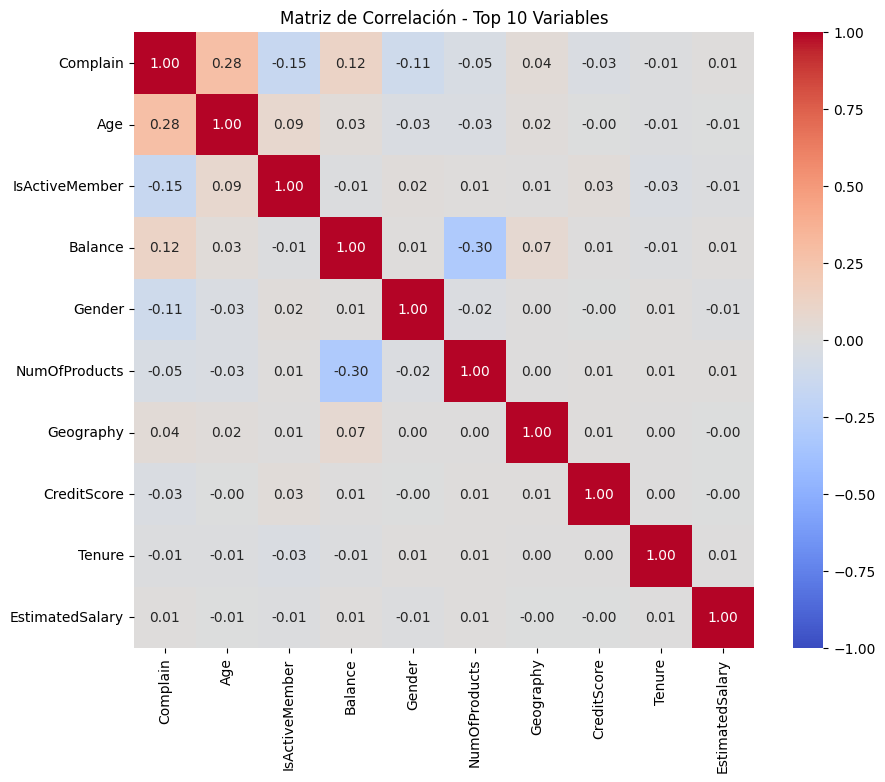

In [8]:
matriz_corr = X_data_churn_filtrado.corr()

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generamos un mapa de calor (heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Top 10 Variables")

XGBoost

In [9]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Calcular el peso para la clase minoritaria (Churn = 1)
conteo_clases = Y_data_churn.value_counts()
peso_positivos = conteo_clases[0] / conteo_clases[1] 

# 2. Configurar StratifiedKFold y el Modelo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=peso_positivos,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# 3. Ejecutar la validación cruzada automáticamente
# n_jobs=-1 usa todos los núcleos de tu procesador para entrenar los pliegues en paralelo
resultados = cross_validate(
    estimator=modelo_xgb,
    X=X_data_churn_filtrado,
    y=Y_data_churn,
    cv=skf,
    scoring=['roc_auc', 'f1'], # Puedes pedir múltiples métricas a la vez
    n_jobs=-1,
    verbose=1
)

# 4. Resultados Globales
print("=== Resumen de Validación Cruzada (Sin For) ===")
print(f"ROC-AUC Promedio: {np.mean(resultados['test_roc_auc']):.4f} (+/- {np.std(resultados['test_roc_auc']):.4f})")
print(f"F1-Score Promedio: {np.mean(resultados['test_f1']):.4f} (+/- {np.std(resultados['test_f1']):.4f})")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


=== Resumen de Validación Cruzada (Sin For) ===
ROC-AUC Promedio: 0.9986 (+/- 0.0011)
F1-Score Promedio: 0.9966 (+/- 0.0020)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.1s finished


In [10]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  int64  
 5   Gender              10000 non-null  int64  
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [11]:
df_churn.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425
